In [5]:
import os
import cv2

# Path to the directory containing the .jpg files
input_dir = "300_poisoned_dataset"
output_dir = "300_gaussian_dataset"

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Iterate through all files in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith(".jpg"):
        # Construct full file path
        file_path = os.path.join(input_dir, filename)
        
        # Read the image
        image = cv2.imread(file_path)
        
        # Apply Gaussian blur
        blurred_image = cv2.GaussianBlur(image, (7, 7), 0)
        
        # Save the blurred image to the output directory
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, blurred_image)


print("Gaussian blur applied to all .jpg files in the directory.")

import shutil

# Iterate through all files in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith(".txt"):
        # Construct full file path
        file_path = os.path.join(input_dir, filename)
        
        # Copy the .txt file to the output directory
        shutil.copy(file_path, output_dir)

print("All .txt files have been copied to the output directory.")

Gaussian blur applied to all .jpg files in the directory.
All .txt files have been copied to the output directory.


In [7]:
import cv2
import numpy as np

image = cv2.imread('bulldog_blurred.jpg')
# Sharpening kernel
kernel = np.array([[-1,-1,-1], 
                   [-1, 9,-1], 
                   [-1,-1,-1]])
sharpened = cv2.filter2D(image, -1, kernel)

cv2.imwrite('bulldog_sharpened.jpg', sharpened)
print("Image sharpened and saved as 'bulldog_sharpened.jpg'")

Image sharpened and saved as 'bulldog_sharpened.jpg'


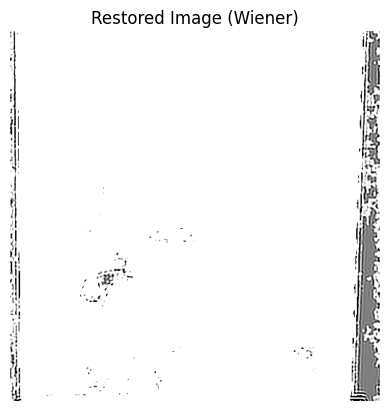

In [16]:
import numpy as np
from skimage.restoration import wiener, richardson_lucy
import cv2
import matplotlib.pyplot as plt

# Load the blurred image (replace 'blurred_image.jpg' with your image path)
# Using OpenCV to read the image
blurred_image_bgr = cv2.imread('bulldog_blurred.jpg')
blurred_image_gray = cv2.cvtColor(blurred_image_bgr, cv2.COLOR_BGR2GRAY) # Wiener works well on grayscale

# Define the Gaussian blur kernel parameters used for blurring
kernel_size = 7 # Example size, should be the original size
sigma = 0     # Example sigma, should be the original sigma

# Create the 2D Gaussian kernel
# Use cv2.getGaussianKernel for convenience, then convert to 2D
gaussian_kernel_1d = cv2.getGaussianKernel(kernel_size, sigma)
psf = np.outer(gaussian_kernel_1d, gaussian_kernel_1d)

# The 'balance' parameter controls the trade-off between noise amplification and deblurring
# A common way to estimate noise power is using the variance of a flat region of the image
# or by simply adjusting it until you get a good result (e.g., 0.01)
balance = 0.01

# Perform Wiener deconvolution
restored_image_gray = wiener(blurred_image_gray, psf, balance=balance)

# Display the result (optional)
plt.imshow(restored_image_gray, cmap='gray')
plt.title("Restored Image (Wiener)")
plt.axis('off')
plt.show()